In [6]:
import numpy as np

a = [(1,2),(4,3)]
b = [(5,7),(1,1)]

a_dot_b = np.einsum('ij,ij->i',a,b)
b_dot_b = np.einsum('ij,ij->i',b,b)

c = a_dot_b/np.sqrt(b_dot_b)
check = (a[0][0]*b[0][0] + a[0][1]*b[0][1])/np.sqrt(b[0][0]*b[0][0] + b[0][1]*b[0][1])

data = np.array(c)
print(a,b)
print(c[0],check)
print(c)


[(1, 2), (4, 3)] [(5, 7), (1, 1)]
2.2087051361325662 2.2087051361325662
[2.20870514 4.94974747]


In [7]:
e = np.linspace(1,10,3)
f = np.linspace(6,15,3)
g = np.linspace(-3,6,3)
h = np.linspace(-8,2,3)

grad_ef = [(e[k],f[k]) for k in range(len(e))]
grad_gh = [(g[k],h[k]) for k in range(len(g))]

g_ef_dot_g_gh = [np.dot(grad_ef[k],grad_gh[k]) for k in range(len(grad_ef))]

print(grad_ef)
print(grad_gh)
print(g_ef_dot_g_gh)

[(1.0, 6.0), (5.5, 10.5), (10.0, 15.0)]
[(-3.0, -8.0), (1.5, -3.0), (6.0, 2.0)]
[-51.0, -23.25, 90.0]


In [80]:
%matplotlib widget
from matplotlib import pyplot as plt

# create vector components
u = 1
v = 1
mag = np.sqrt(u**2 + v**2)

u_hat = u/mag
v_hat = v/mag
theta = np.arctan(u/v)

x0 = 1
y0 = 2

fig,(ax,ax2) = plt.subplots(1,2,figsize=(10,5))
ax.quiver(x0,y0,u_hat,v_hat)
ax.set(ylabel="y", xlabel="x",xlim=[0,10],ylim=[0,10],title=f"theta={theta*180/np.pi:0.3f}deg")
# ax2.quiver(x0,np.log10(y0),u_hat,np.log(10)*y0*v_hat)
ax2.quiver(x0,np.log10(y0),u_hat,v_hat, color='r',alpha = 0.2)
ax2.set(ylabel="y", xlabel="x", xlim=[0,10],ylim=[-2,1],title=f"theta={theta*180/np.pi:0.3f}deg")

# plt.show()
plt.close()

dfdx = 0.874, dfdy = 0.486, ln(10)y0 = 0.115
x0+dfdx=0.964, y0+dfdy = 0.536
log10(y0+dfdy) = -0.271
arccos(x0 + dfdx) = 0.2685


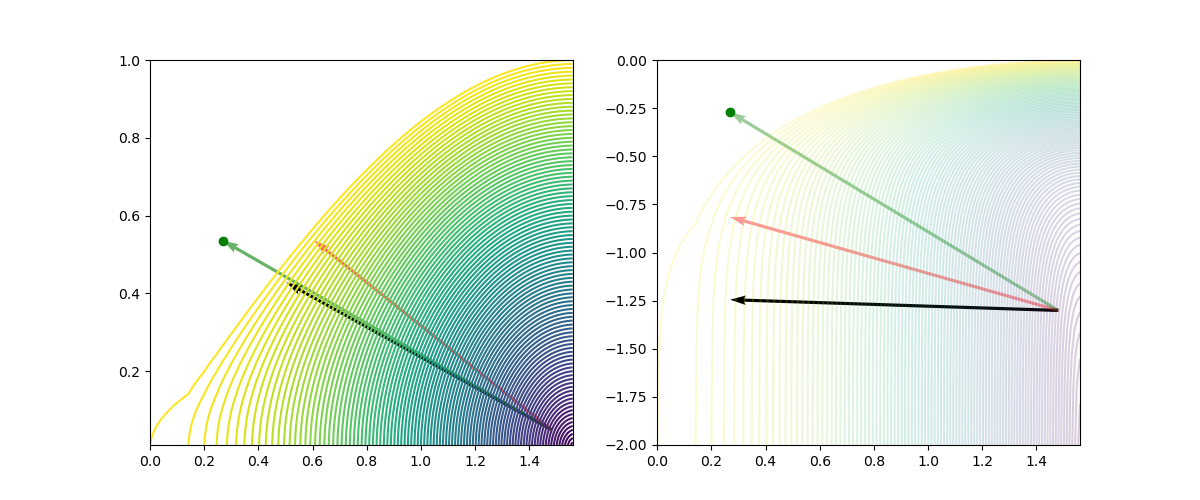

In [162]:
x = np.linspace(0.01,1,100)
y = np.linspace(0.01,1,100)

xg,yg = np.meshgrid(x,y)

def fn(x,y):
    return np.sqrt(x**2 + y**2)

def dfdx_fn(x,y):
    return x/fn(x,y)

def dfdy_fn(x,y):
    return y/fn(x,y)

f = fn(xg,yg)
x0 = 0.09
y0 = 0.05

deltay = np.log10((y0+dfdy)) - np.log10(y0)

dfdx = dfdx_fn(x0,y0)
dfdy = dfdy_fn(x0,y0)
fig,(ax,ax2) = plt.subplots(1,2,figsize=(12,5))
ax.contour(np.arccos(xg),yg,f,levels=x)
ax.quiver(np.arccos(x0),y0,-(dfdx),dfdy, angles='uv',scale=1,scale_units='xy')
ax.quiver(np.arccos(x0),y0,-(dfdx),dfdy, angles='xy',color='r',scale=1,alpha =0.6,scale_units='xy')
ax.quiver(np.arccos(x0),y0,np.arccos(x0 + dfdx) - np.arccos(x0),dfdy, angles='xy',color='g',scale=1,alpha =0.6,scale_units='xy')

ax.scatter(np.arccos(x0+dfdx),y0+dfdy,color='g')
ax2.contour(np.arccos(xg),np.log10(yg),f,levels=x,alpha =0.2)
ax2.quiver(np.arccos(x0),np.log10(y0),np.arccos(x0+dfdx)-np.arccos(x0),dfdy*(np.log(10)*y0), angles='xy',scale_units='xy',scale=1)
ax2.quiver(np.arccos(x0),np.log10(y0),np.arccos(x0+dfdx)-np.arccos(x0),dfdy, color='r',alpha=0.4, angles='xy',scale_units='xy',scale=1)
ax2.quiver(np.arccos(x0),np.log10(y0),np.arccos(x0+dfdx)-np.arccos(x0),deltay, color='g',alpha=0.4, angles='xy',scale_units='xy',scale=1)

ax2.scatter(np.arccos(x0+dfdx),np.log10(y0+dfdy),color='g')
print(f"dfdx = {dfdx:0.3f}, dfdy = {dfdy:0.3f}, ln(10)y0 = {np.log(10)*y0:0.3f}")
print(f"x0+dfdx={x0 + dfdx:0.3f}, y0+dfdy = {y0 + dfdy:0.3f}")
print(f"log10(y0+dfdy) = {np.log10(y0+dfdy):0.3f}")
print(f"arccos(x0 + dfdx) = {np.arccos(x0+dfdx):0.4f}")
plt.show()
